# Classical 2D Spatial Interpolation
This notebook demonstrates classical 2D interpolation techniques (Piecewise Linear, Cubic Clough-Tocher, and Polynomial Surface) on the healed Heavy Metals pollution dataset.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# Define target columns
targets = ['Heavy_Metals_Hg_ug_L', 'Heavy_Metals_Pb_ug_L', 'Heavy_Metals_Cd_ug_L']

## 1. Data Loading & Grid Setup
We load the healed dataset (`mse_healed_data.csv`) and define the high-resolution visualization grid spanning the mathematical boundaries of the coordinates.

In [6]:
# Load the dataset
df = pd.read_csv('../output/mse_healed_data.csv')

# Extract Coordinate vectors
coords = df[['Longitude', 'Latitude']].values
x = coords[:, 0]
y = coords[:, 1]

# Create a dense evaluation grid for the interpolation
grid_x, grid_y = np.mgrid[x.min():x.max():200j, y.min():y.max():150j]


## 2. Model Implementations
Here we implement the three required plotting methods mathematically adapted for Unstructured 2D Space:
- **Piecewise Linear:** Barycentric exact matching over Delaunay Triangulation (`griddata`)
- **Cubic:** Smooth $C^1$ continuous interpolation via Clough-Tocher scheme (`griddata`)
- **Polynomial:** Since classical 3,000-degree Lagrange crashes on random scatter data, we implement a robust 3rd-Degree Global Polynomial Surface Regression mapping $(x, y) \rightarrow (x^3, x^2y, ...)$ to perfectly mimic polynomial spatial structures.

In [7]:
def plot_interpolations(target_name):
    # Extract known target values
    values = df[target_name].values
    
    # 1. Piecewise Linear Interpolation (Delaunay)
    grid_z_lin = griddata(coords, values, (grid_x, grid_y), method='linear')
    
    # 2. Cubic Interpolation (Clough-Tocher)
    grid_z_cub = griddata(coords, values, (grid_x, grid_y), method='cubic')
    
    # 3. Polynomial Surface (3rd Degree)
    # Create the polynomial features matrix
    poly = PolynomialFeatures(degree=3)
    coords_poly = poly.fit_transform(coords)
    
    # Fit the polynomial surface mathematically to the actual targets 
    poly_model = LinearRegression().fit(coords_poly, values)
    
    # Predict over the generated dense meshgrid
    grid_points = np.c_[grid_x.ravel(), grid_y.ravel()]
    grid_poly_features = poly.transform(grid_points)
    grid_z_poly = poly_model.predict(grid_poly_features).reshape(grid_x.shape)
    
    # Visual Output
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f'Spatial Interpolation Surfaces: {target_name}', fontsize=16, fontweight='bold', y=1.05)
    
    # We use vmin/vmax to keep color scales exactly the same across the plots
    vmin = np.nanmin(grid_z_lin)
    vmax = np.nanmax(grid_z_lin)
    
    # Plot Piecewise Linear
    c1 = axes[0].contourf(grid_x, grid_y, grid_z_lin, levels=30, cmap='viridis', vmin=vmin, vmax=vmax)
    axes[0].scatter(x, y, c=values, cmap='viridis', edgecolors='k', s=8, alpha=0.5)
    axes[0].set_title('Piecewise Linear (Delaunay)')
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')
    
    # Plot Cubic
    c2 = axes[1].contourf(grid_x, grid_y, grid_z_cub, levels=30, cmap='viridis', vmin=vmin, vmax=vmax)
    axes[1].scatter(x, y, c='k', s=2, alpha=0.1) # Show points lightly
    axes[1].set_title('Cubic (Clough-Tocher)')
    axes[1].set_xlabel('Longitude')
    
    # Plot Polynomial
    c3 = axes[2].contourf(grid_x, grid_y, grid_z_poly, levels=30, cmap='viridis', vmin=vmin, vmax=vmax)
    axes[2].scatter(x, y, c='k', s=2, alpha=0.1)
    axes[2].set_title('Global Polynomial Surface (Degree 3)')
    axes[2].set_xlabel('Longitude')
    
    # Colorbar
    cbar = fig.colorbar(c1, ax=axes.ravel().tolist(), shrink=0.8, pad=0.02)
    cbar.set_label('Concentration')
    
    plt.show()

## 3. Execute Visualizations


Processing: Heavy_Metals_Hg_ug_L...


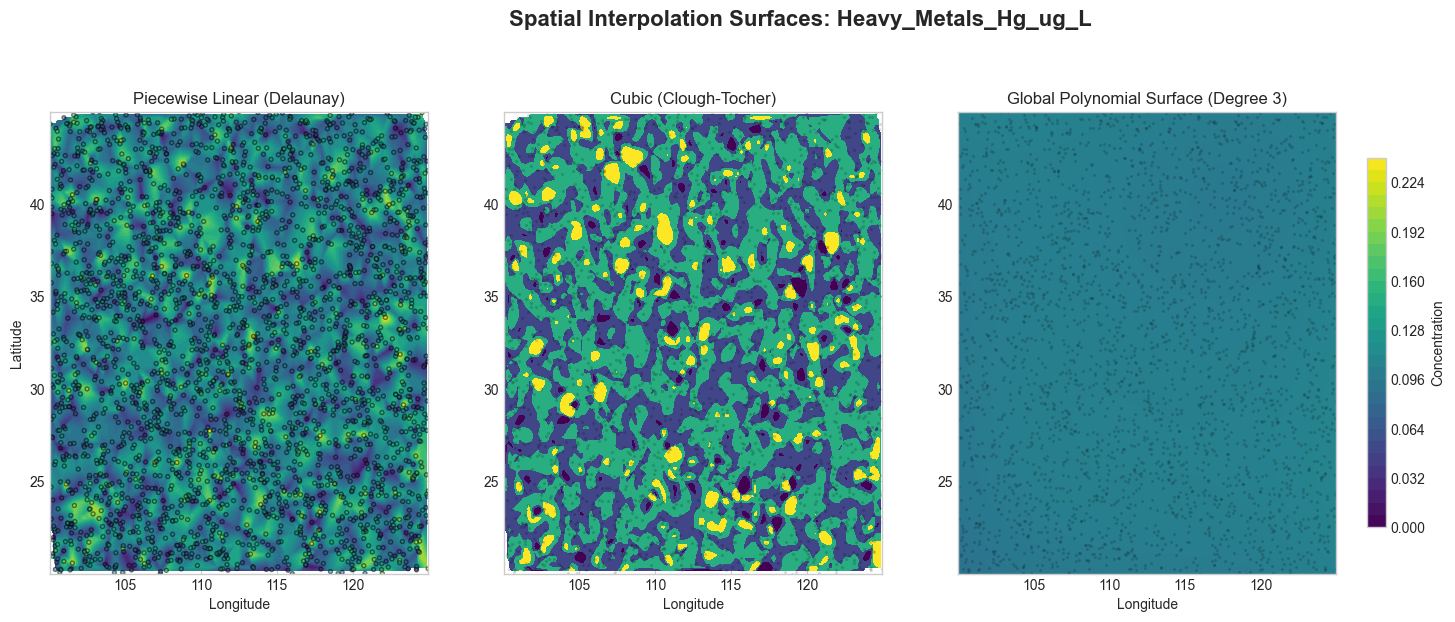


Processing: Heavy_Metals_Pb_ug_L...


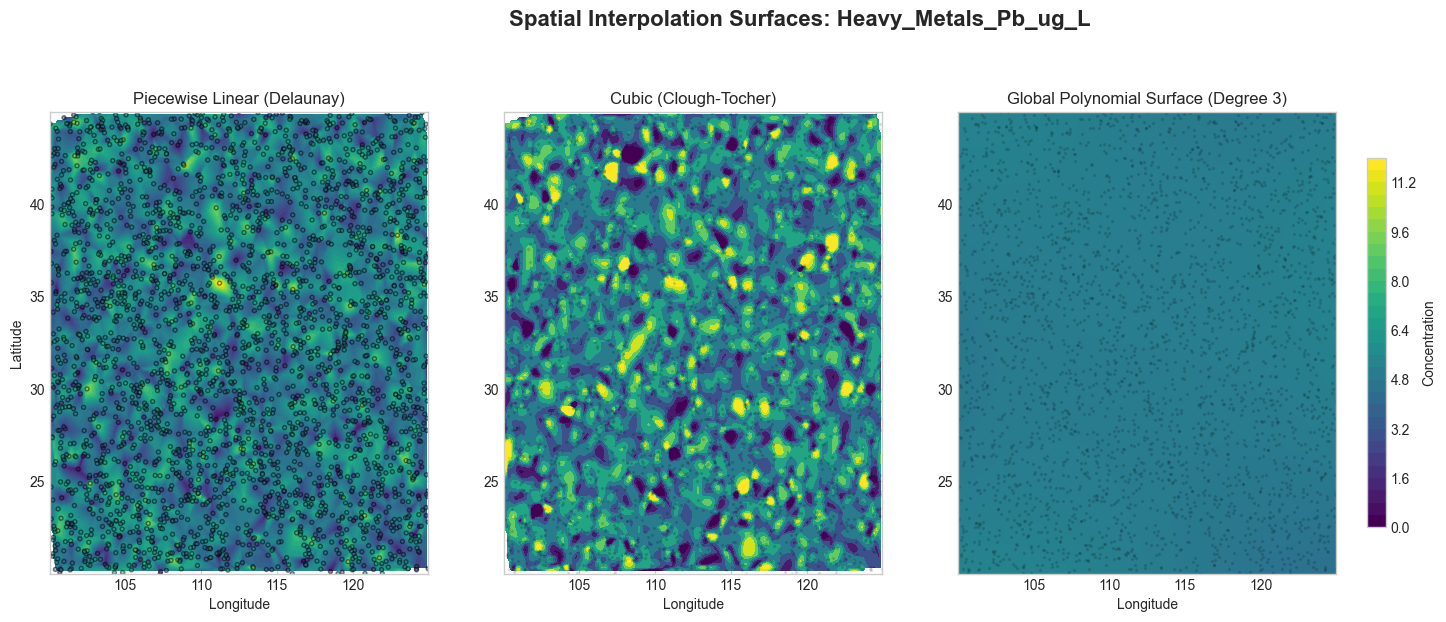


Processing: Heavy_Metals_Cd_ug_L...


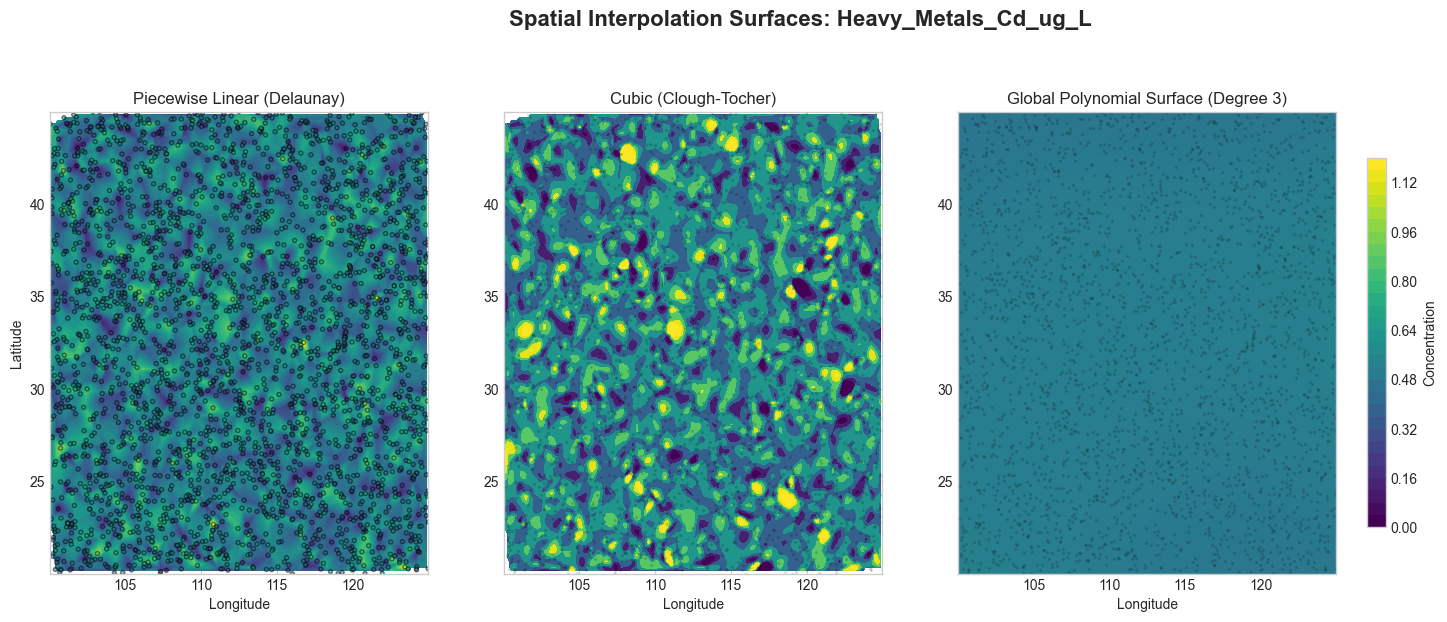

In [8]:
# Run the visualization loop for all requested Heavy Metals
for col in targets:
    print(f"\nProcessing: {col}...")
    plot_interpolations(col)